In [1]:
import pandas as pd
import os
import requests
from tqdm import tqdm

In [2]:
def download_pdb(pdb_id, save_dir='pdb_files', timeout=10, max_retries=3):
    """
    使用 requests 下载 PDB 文件
    :param pdb_id: PDB 标识符（如 '1abc'）
    :param save_dir: 保存目录（默认 'pdb_files'）
    :param timeout: 超时时间（秒）
    :return: 成功返回保存路径，失败返回 None
    """
    pdb_id = pdb_id.lower()  # PDB ID 需小写
    os.makedirs(save_dir, exist_ok=True)  # 确保保存目录存在
    # url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    # url = f"https://www.ebi.ac.uk/pdbe/entry-files/download/pdb{pdb_id}.ent"
    save_path = os.path.join(save_dir, f"{pdb_id}.pdb")
    # save_path = save_dir
    if os.path.exists(save_path):
        print(f"PDB文件已存在：{save_path}")
        return True, os.path.abspath(save_path)

    for retry in range(max_retries):
        try:
            # url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
            url = f"https://www.ebi.ac.uk/pdbe/entry-files/download/pdb{pdb_id}.ent"
            response = requests.get(url, stream=True, timeout=timeout)
            response.raise_for_status()

            file_size = int(response.headers.get('content-length', 0))
            with open(save_path, 'wb') as f, tqdm(
                    desc=f"下载 {pdb_id}（第{retry + 1}/{max_retries}次）",
                    total=file_size,
                    unit='B',
                    unit_scale=True,
                    leave=True
            ) as pbar:
                for chunk in response.iter_content(chunk_size=1024):
                    if chunk:
                        f.write(chunk)
                        pbar.update(len(chunk))
            return True, save_path

        except requests.exceptions.Timeout:
            if retry < max_retries - 1:
                print(f"第{retry + 1}次超时，重试（剩余{max_retries - retry - 1}次）...")
                continue
            else:
                return False, f"超时失败（{max_retries}次）"

        except requests.exceptions.ConnectionError:
            if retry < max_retries - 1:
                print(f"第{retry + 1}次连接失败，重试（剩余{max_retries - retry - 1}次）...")
                continue
            else:
                return False, f"连接失败（{max_retries}次）"

        except requests.exceptions.HTTPError as e:
            return False, f"HTTP错误：{e}（PDB ID可能无效）"

        except Exception as e:
            return False, f"下载失败：{str(e)}"
    return None

In [3]:
cdna2 = pd.read_csv("./predictions/cdna2_processed_with_prediction.csv")
pdb_count = cdna2["pdb_id"].value_counts().to_dict()
for pdb_id, value in pdb_count.items():
    download_pdb(pdb_id, save_dir='pdbs')

下载 2kgt（第1/3次）: 100%|██████████| 1.86M/1.86M [00:02<00:00, 641kB/s] 
下载 1y0m（第1/3次）: 100%|██████████| 132k/132k [00:01<00:00, 122kB/s]  
下载 3i35（第1/3次）: 100%|██████████| 69.7k/69.7k [00:00<00:00, 114kB/s] 
下载 1gl5（第1/3次）: 100%|██████████| 1.78M/1.78M [00:07<00:00, 244kB/s] 
下载 1zlm（第1/3次）: 100%|██████████| 121k/121k [00:01<00:00, 116kB/s]  
下载 4uzw（第1/3次）: 100%|██████████| 1.29M/1.29M [00:04<00:00, 293kB/s] 
下载 6nmw（第1/3次）: 100%|██████████| 162k/162k [00:01<00:00, 133kB/s]  
下载 4hck（第1/3次）: 100%|██████████| 1.98M/1.98M [00:05<00:00, 380kB/s] 
下载 1h92（第1/3次）: 100%|██████████| 2.37M/2.37M [00:09<00:00, 245kB/s] 
下载 1o6x（第1/3次）: 100%|██████████| 2.12M/2.12M [00:06<00:00, 320kB/s] 
下载 1qly（第1/3次）: 100%|██████████| 1.56M/1.56M [00:07<00:00, 220kB/s] 
下载 2wqg（第1/3次）: 100%|██████████| 1.63M/1.63M [00:02<00:00, 712kB/s] 
下载 2ami（第1/3次）: 100%|██████████| 1.97M/1.97M [00:02<00:00, 743kB/s] 
下载 1w4g（第1/3次）: 100%|██████████| 1.19M/1.19M [00:02<00:00, 424kB/s] 
下载 2lp5（第1/3次）: 100%|██████████| 763k

In [4]:
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import three_to_one, is_aa

def get_pdb_sequence(pdb_file_path, chain_id=None):
    """
    从本地PDB文件中提取蛋白质氨基酸序列（单字母缩写）
    :param pdb_file_path: 本地PDB文件的路径（如 "./1abc.pdb"）
    :param chain_id: 可选参数，指定提取某条链的序列（如 "A"、"B"），不指定则提取所有链
    :return: 拼接后的蛋白质单字母序列
    """
    # 1. 初始化PDB解析器，QUIET=True 关闭无关的警告信息（避免输出冗余内容）
    pdb_parser = PDBParser(QUIET=True)

    try:
        # 2. 解析PDB文件，生成结构对象（参数1：结构名称，可自定义；参数2：PDB文件路径）
        structure = pdb_parser.get_structure("target_protein", pdb_file_path)
    except FileNotFoundError:
        return f"错误：找不到指定的PDB文件 -> {pdb_file_path}"
    except Exception as e:
        return f"错误：解析PDB文件失败 -> {str(e)}"

    # 3. 初始化列表，用于存储单个氨基酸的单字母缩写
    aa_sequence = []

    # 4. 遍历结构对象，提取残基信息（PDB结构层级：Structure → Model → Chain → Residue → Atom）
    # 优先取第一个模型（大部分PDB文件只有1个模型，NMR结构可能有多个模型，这里默认取第一个）
    first_model = next(structure.get_models())

    for chain in first_model:
        # 如果指定了链ID，只处理该链，跳过其他链
        if chain_id is not None and chain.get_id() != chain_id:
            continue

        for residue in chain:
            # 5. 过滤：只保留标准氨基酸残基（排除水分子、配体、辅因子、离子等非氨基酸成分）
            # standard=True 表示只筛选20种常见标准氨基酸
            if is_aa(residue, standard=True):
                try:
                    # 6. 将氨基酸三字母缩写（如 "LYS"）转换为单字母缩写（如 "K"）
                    aa_single = three_to_one(residue.get_resname())
                    aa_sequence.append(aa_single)
                except KeyError:
                    # 极少数非标准氨基酸无法转换，用 "X" 表示未知氨基酸
                    aa_sequence.append("X")

    # 7. 拼接列表为完整字符串，返回最终序列
    return "".join(aa_sequence)

In [5]:
valid_pdb = []
for pdb_id in pdb_count.keys():
    pdb_dir = f"pdbs/{pdb_id.lower()}.pdb"
    pdb_seq = get_pdb_sequence(pdb_dir)
    wt_seq = cdna2[cdna2["pdb_id"] == pdb_id]["wt_seq"].values[0]
    if pdb_seq == wt_seq:
        valid_pdb.append(pdb_id)
        print(f'有效PDB：{pdb_id}')

有效PDB：3i35
有效PDB：1qly
有效PDB：2o2w


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr  # 核密度+相关系数

def plot_fig(df, pdb_id):
    ddg_stats = df["ddg"].describe()

    # ===============================
    # 3. 绘制
    # ===============================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    # 定义统一的样式参数（关键：保证图例和文本框样式一致）
    BOX_STYLE = {
        'boxstyle': 'round',
        'facecolor': 'white',
        'edgecolor': 'black',
        'alpha': 0.8,
        'linewidth': 1.2
    }
    TEXT_FONT_SIZE = 12
    LEGEND_FONT_SIZE = 12

    # ------------------------------
    # 3.1 子图1:ΔΔG分布直方图
    # ------------------------------
    # 绘制直方图
    sns.histplot(df["ddg"], bins=20, kde=True, color="skyblue", edgecolor="black", ax=ax1)

    # 绘制均值和中位数竖线
    ax1.axvline(ddg_stats["mean"], color="red", linestyle="--", label=f"Mean: {ddg_stats['mean']:.2f}")
    ax1.axvline(ddg_stats["50%"], color="orange", linestyle="--", label=f"Median: {ddg_stats['50%']:.2f}")

    # 全英文标题与轴标签
    ax1.set_title(f"Double Mutation ΔΔG Distribution ({pdb_id.upper()})", fontsize=16, pad=20)
    ax1.set_xlabel("Experimental ΔΔG (kcal/mol)", fontsize=14, labelpad=10)
    ax1.set_ylabel("Frequency", fontsize=14, labelpad=10)

    # 添加图例
    legend = ax1.legend(
        fontsize=LEGEND_FONT_SIZE,
        frameon=True,
        facecolor=BOX_STYLE['facecolor'],
        edgecolor=BOX_STYLE['edgecolor'],
        loc='upper left'  # 统一位置风格
    )
    # 设置图例边框宽度（matplotlib兼容写法）
    for frame in legend.get_frame().get_children():
        if isinstance(frame, plt.Line2D):
            frame.set_linewidth(BOX_STYLE['linewidth'])

    # 优化刻度
    ax1.tick_params(axis="both", labelsize=12)


    # ------------------------------
    # 3.2 子图2
    # ------------------------------
    x = df['PreDDG']
    y = df['ddg']
    # ==================== 2. 计算核密度（用于颜色映射） ====================
    # 堆叠数据并计算KDE
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)  # 每个点的密度值
    idx = z.argsort()  # 按密度排序（确保高密度点在顶层）
    x_sorted, y_sorted, z_sorted = x[idx], y[idx], z[idx]

    # ==================== 3. 计算统计量（pcc和p值） ====================
    spear, _ = spearmanr(x, y)

    # 绘制密度散点图：按密度上色
    # 配色：从黄到紫的渐变（匹配示例）
    cmap = plt.cm.YlOrRd_r  # 反向YlOrRd（黄→红→紫）
    scatter = ax2.scatter(
        x_sorted, y_sorted,
        c=z_sorted,
        s=20,  # 点的大小
        cmap=cmap,
        alpha=0.8,
        edgecolors="none",
        rasterized=True  # 提升保存图片质量
    )
    # 添加颜色条（右侧）
    cbar = plt.colorbar(scatter, ax=ax2)

    # 添加统计信息文本框
    text_str = f"SCC = {spear:.2f}"
    ax2.text(
        0.05, 0.95, text_str,
        transform=ax2.transAxes,
        fontsize=TEXT_FONT_SIZE,
        verticalalignment="top",
        bbox=BOX_STYLE,  # 直接使用统一的样式字典
        # family='Arial'   # 确保字体统一
    )

    # 调整坐标轴范围
    ax2.set_xlim(-2, 3)
    ax2.set_ylim(-2, 5.5)

    # 设置标签
    ax2.set_xlabel("PreDDG predictions (kcal/mol)", fontsize=14, labelpad=10)
    ax2.set_ylabel("Experimental ΔΔG (kcal/mol)", fontsize=14, labelpad=10)
    ax2.set_title("PreDDG Predictions vs Experimental ΔΔG", fontsize=16, pad=20)

    # 优化刻度
    ax2.tick_params(axis="both", labelsize=12)

    # ===============================
    # 4. 全局优化 & 保存
    # ===============================
    plt.tight_layout(pad=3.0, w_pad=6.0)

    # 保存高分辨率图片
    plt.savefig(
        f"./{pdb_id}_ddg_ditribution_pre_ddg_scatter.svg",
        dpi=300,                # 矢量图仍需指定dpi（影响嵌入时的分辨率）
        bbox_inches='tight',    # 裁剪多余空白
        facecolor='white',      # 背景色（避免透明）
        edgecolor='none',       # 无边框
        format='svg'            # 显式指定格式（兼容所有Matplotlib版本）
    )
    plt.show()

def process_df(pdb_id):
    df = cdna2[cdna2["pdb_id"] == pdb_id].copy()
    df_dedup = df.groupby("mut_info").agg(
        pdb_id=("pdb_id", "first"),
        ddg=("ddg", "mean"),
        PreDDG=("PreDDG", "mean"),
        mut_info=("mut_info", "first"),
        mut_info1=("mut_info1", "first"),
        mut_info2=("mut_info2", "first"),
        pos1=("pos1", "first"),
        fr1=("fr1", "first"),
        to1=("to1", "first"),
        pos2=("pos2", "first"),
        fr2=("fr2", "first"),
        to2=("to2", "first"),
        mut_seq=("mut_seq", "first"),
        wt_seq=("wt_seq", "first"),
    ).reset_index(drop=True)
    return df_dedup

3i35 2080


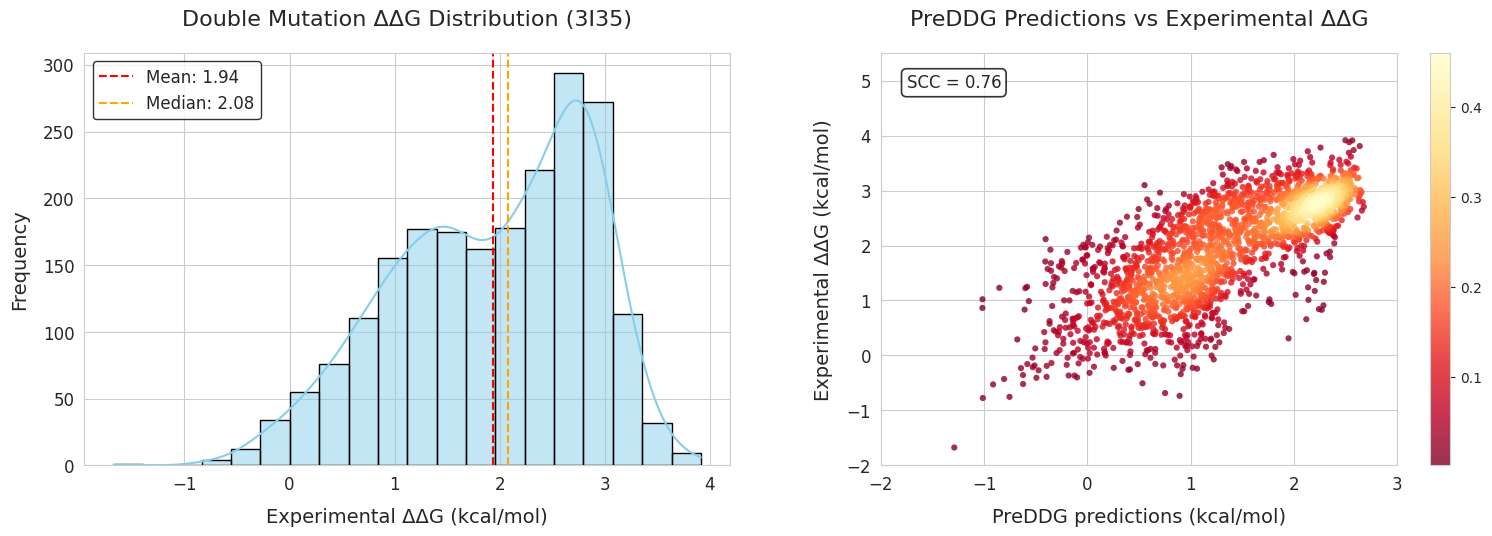

1qly 692


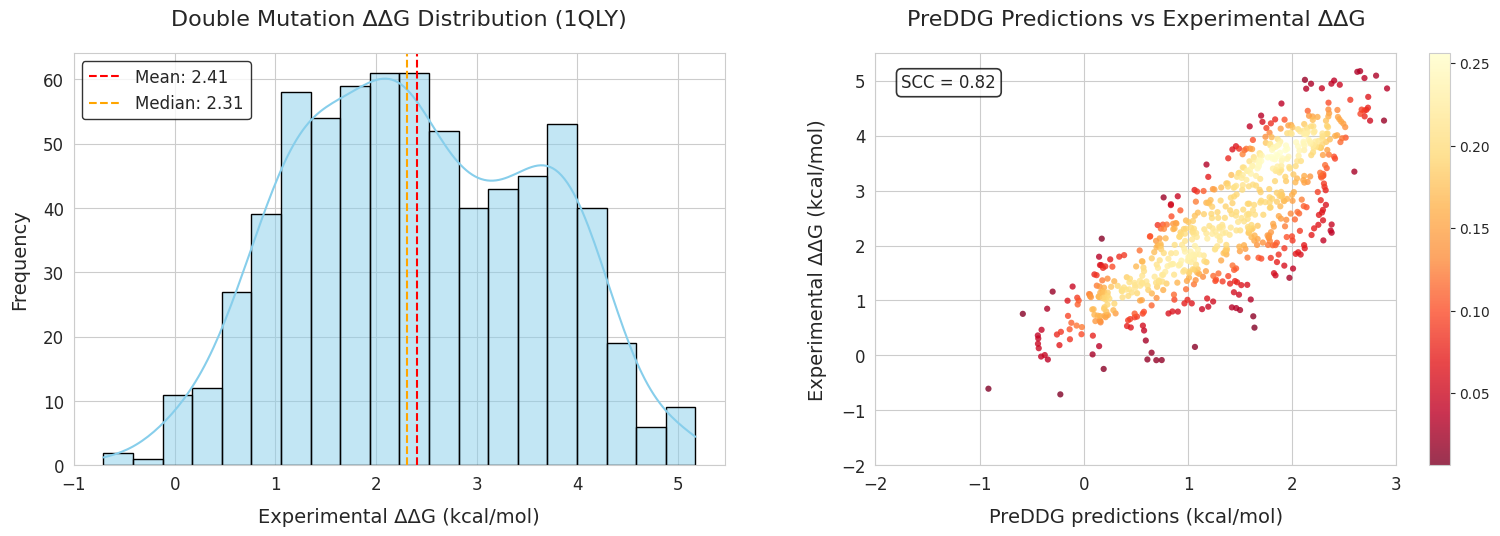

2o2w 349


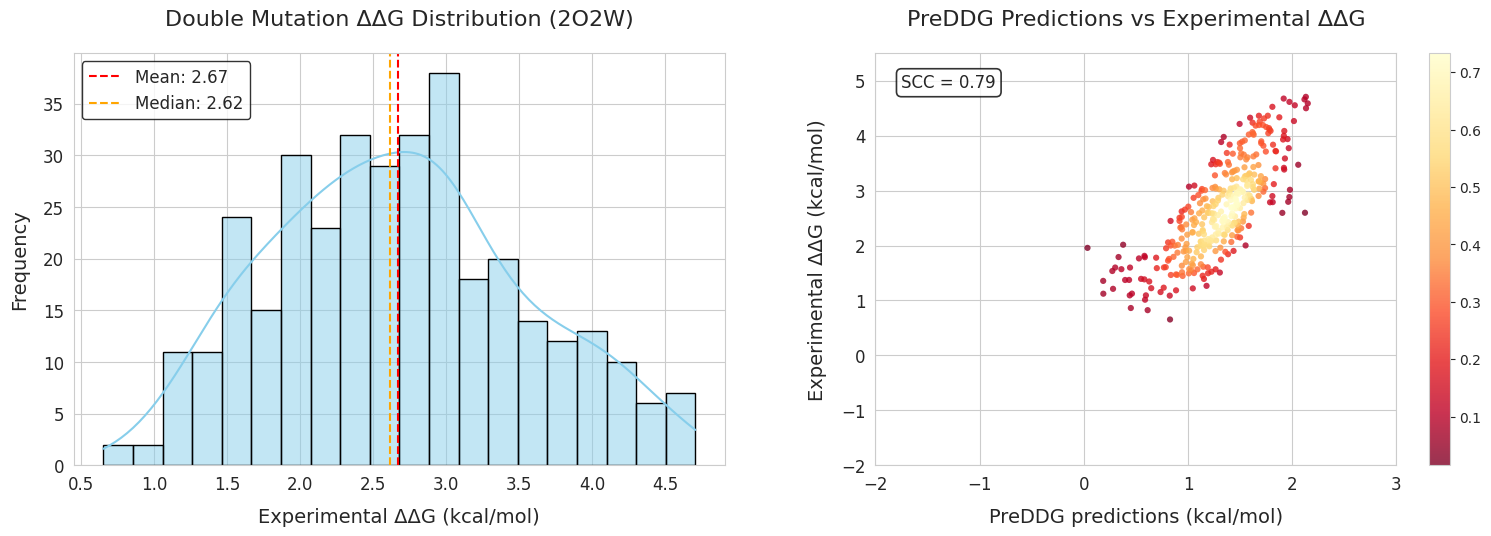

In [7]:
for pdb_id in valid_pdb:
    df_dedup = process_df(pdb_id)
    print(pdb_id, len(df_dedup))
    plot_fig(df_dedup, pdb_id)

In [8]:
df_dedup = process_df('1qly')
df_dedup

,pdb_id,ddg,PreDDG,mut_info,mut_info1,mut_info2,pos1,fr1,to1,pos2,fr2,to2,mut_seq,wt_seq
0,1qly,1.929929,1.093900,R40A:E46A,R40A,E46A,40,R,A,46,E,A,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRAADKNGQA...,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...
1,1qly,1.460441,0.122543,R40A:E46C,R40A,E46C,40,R,A,46,E,C,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRAADKNGQC...,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...
2,1qly,2.686360,1.785595,R40A:E46D,R40A,E46D,40,R,A,46,E,D,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRAADKNGQD...,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...
3,1qly,2.026154,0.736620,R40A:E46F,R40A,E46F,40,R,A,46,E,F,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRAADKNGQF...,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...
4,1qly,3.194922,1.560484,R40A:E46G,R40A,E46G,40,R,A,46,E,G,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRAADKNGQG...,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687,1qly,1.149785,1.440478,Y10W:Y53R,Y10W,Y53R,10,Y,W,53,Y,R,LKKVVALYDWMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...
688,1qly,0.826345,1.499337,Y10W:Y53S,Y10W,Y53S,10,Y,W,53,Y,S,LKKVVALYDWMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...
689,1qly,2.011107,1.367683,Y10W:Y53T,Y10W,Y53T,10,Y,W,53,Y,T,LKKVVALYDWMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...
690,1qly,1.469077,0.866365,Y10W:Y53V,Y10W,Y53V,10,Y,W,53,Y,V,LKKVVALYDWMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...,LKKVVALYDYMPMNANDLQLRKGDEYFILEESNLPWWRARDKNGQE...


In [9]:
df_dedup['poss'] = df_dedup['pos1'].astype(str) + '_' + df_dedup['pos2'].astype(str)
df_dedup['poss'].unique()

array(['40_46', '10_53'], dtype=object)

In [10]:
df_dedup = process_df('3i35')
df_dedup

,pdb_id,ddg,PreDDG,mut_info,mut_info1,mut_info2,pos1,fr1,to1,pos2,fr2,to2,mut_seq,wt_seq
0,3i35,2.422714,1.955459,D23A:R42A,D23A,R42A,23,D,A,42,R,A,KRYRAVYDYSAADEDEVSFQDGATIVNVQQIDDGWMYGTVEATGDT...,KRYRAVYDYSAADEDEVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...
1,3i35,2.262053,1.613844,D23A:R42C,D23A,R42C,23,D,A,42,R,C,KRYRAVYDYSAADEDEVSFQDGATIVNVQQIDDGWMYGTVECTGDT...,KRYRAVYDYSAADEDEVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...
2,3i35,2.533397,1.836911,D23A:R42D,D23A,R42D,23,D,A,42,R,D,KRYRAVYDYSAADEDEVSFQDGATIVNVQQIDDGWMYGTVEDTGDT...,KRYRAVYDYSAADEDEVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...
3,3i35,2.330451,1.902567,D23A:R42E,D23A,R42E,23,D,A,42,R,E,KRYRAVYDYSAADEDEVSFQDGATIVNVQQIDDGWMYGTVEETGDT...,KRYRAVYDYSAADEDEVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...
4,3i35,2.689205,2.110413,D23A:R42F,D23A,R42F,23,D,A,42,R,F,KRYRAVYDYSAADEDEVSFQDGATIVNVQQIDDGWMYGTVEFTGDT...,KRYRAVYDYSAADEDEVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075,3i35,1.736434,1.572569,Y9W:E16S,Y9W,E16S,9,Y,W,16,E,S,KRYRAVYDWSAADEDSVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...,KRYRAVYDYSAADEDEVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...
2076,3i35,2.030309,1.365961,Y9W:E16T,Y9W,E16T,9,Y,W,16,E,T,KRYRAVYDWSAADEDTVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...,KRYRAVYDYSAADEDEVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...
2077,3i35,2.414667,1.757061,Y9W:E16V,Y9W,E16V,9,Y,W,16,E,V,KRYRAVYDWSAADEDVVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...,KRYRAVYDYSAADEDEVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...
2078,3i35,2.109798,0.801706,Y9W:E16W,Y9W,E16W,9,Y,W,16,E,W,KRYRAVYDWSAADEDWVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...,KRYRAVYDYSAADEDEVSFQDGDTIVNVQQIDDGWMYGTVERTGDT...


In [11]:
df_dedup['poss'] = df_dedup['pos1'].astype(str) + '_' + df_dedup['pos2'].astype(str)
df_dedup['poss'].unique()

array(['23_42', '27_39', '27_46', '2_41', '39_46', '9_16'], dtype=object)

In [12]:
df_dedup = process_df('2o2w')
df_dedup

,pdb_id,ddg,PreDDG,mut_info,mut_info1,mut_info2,pos1,fr1,to1,pos2,fr2,to2,mut_seq,wt_seq
0,2o2w,2.267258,1.292665,E29A:R51A,E29A,R51A,29,E,A,51,R,A,GIDPFTGEAIAKFNFNGDTQVEMSFRKGARITLLRQVDENWYEGRI...,GIDPFTGEAIAKFNFNGDTQVEMSFRKGERITLLRQVDENWYEGRI...
1,2o2w,1.565757,1.090377,E29A:R51C,E29A,R51C,29,E,A,51,R,C,GIDPFTGEAIAKFNFNGDTQVEMSFRKGARITLLRQVDENWYEGRI...,GIDPFTGEAIAKFNFNGDTQVEMSFRKGERITLLRQVDENWYEGRI...
2,2o2w,2.675004,1.459396,E29A:R51D,E29A,R51D,29,E,A,51,R,D,GIDPFTGEAIAKFNFNGDTQVEMSFRKGARITLLRQVDENWYEGRI...,GIDPFTGEAIAKFNFNGDTQVEMSFRKGERITLLRQVDENWYEGRI...
3,2o2w,2.325981,1.332634,E29A:R51E,E29A,R51E,29,E,A,51,R,E,GIDPFTGEAIAKFNFNGDTQVEMSFRKGARITLLRQVDENWYEGRI...,GIDPFTGEAIAKFNFNGDTQVEMSFRKGERITLLRQVDENWYEGRI...
4,2o2w,1.994824,1.122413,E29A:R51F,E29A,R51F,29,E,A,51,R,F,GIDPFTGEAIAKFNFNGDTQVEMSFRKGARITLLRQVDENWYEGRI...,GIDPFTGEAIAKFNFNGDTQVEMSFRKGERITLLRQVDENWYEGRI...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,2o2w,2.845388,1.608951,E29Y:R51S,E29Y,R51S,29,E,Y,51,R,S,GIDPFTGEAIAKFNFNGDTQVEMSFRKGYRITLLRQVDENWYEGRI...,GIDPFTGEAIAKFNFNGDTQVEMSFRKGERITLLRQVDENWYEGRI...
345,2o2w,3.168571,1.679637,E29Y:R51T,E29Y,R51T,29,E,Y,51,R,T,GIDPFTGEAIAKFNFNGDTQVEMSFRKGYRITLLRQVDENWYEGRI...,GIDPFTGEAIAKFNFNGDTQVEMSFRKGERITLLRQVDENWYEGRI...
346,2o2w,2.854509,1.456069,E29Y:R51V,E29Y,R51V,29,E,Y,51,R,V,GIDPFTGEAIAKFNFNGDTQVEMSFRKGYRITLLRQVDENWYEGRI...,GIDPFTGEAIAKFNFNGDTQVEMSFRKGERITLLRQVDENWYEGRI...
347,2o2w,2.512121,1.155290,E29Y:R51W,E29Y,R51W,29,E,Y,51,R,W,GIDPFTGEAIAKFNFNGDTQVEMSFRKGYRITLLRQVDENWYEGRI...,GIDPFTGEAIAKFNFNGDTQVEMSFRKGERITLLRQVDENWYEGRI...


In [13]:
df_dedup['poss'] = df_dedup['pos1'].astype(str) + '_' + df_dedup['pos2'].astype(str)
df_dedup['poss'].unique()

array(['29_51'], dtype=object)